In [44]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [45]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

In [46]:
# Membaca dataset dari Google Drive
df = pd.read_csv('/content/drive/MyDrive/Stunting KNN/data_balita.csv')

# Menampilkan dataset
df.head()

,Umur (bulan),Jenis Kelamin,Tinggi Badan (cm),Status Gizi
0,0,laki-laki,44.591973,stunted
1,0,laki-laki,56.705203,tinggi
2,0,laki-laki,46.863358,normal
3,0,laki-laki,47.508026,normal
4,0,laki-laki,42.743494,severely stunted


<ipython-input-47-7dda70d257a0>:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Jenis Kelamin', y='Count', data=gender_counts_df, palette='viridis')
<ipython-input-47-7dda70d257a0>:14: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.barplot(x='Jenis Kelamin', y='Count', data=gender_counts_df, palette='viridis')


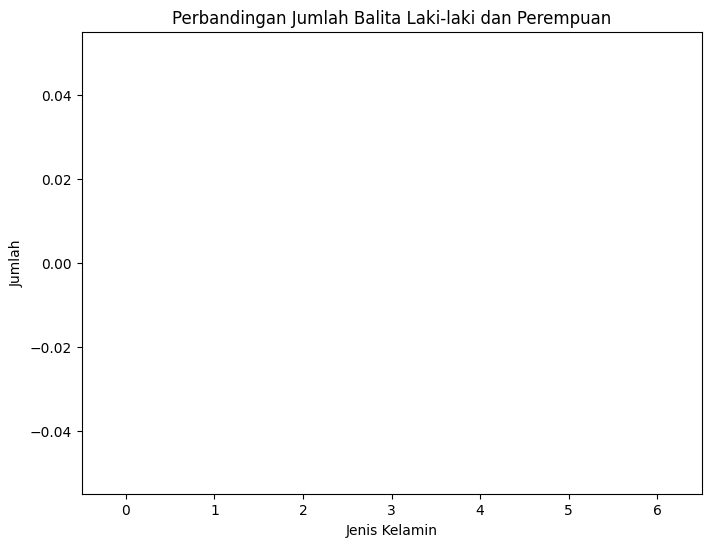

In [47]:
import matplotlib.pyplot as plt
import seaborn as sns

# Menghitung jumlah balita berdasarkan jenis kelamin
gender_counts = df['Jenis Kelamin'].value_counts()

# Mengonversi hasil ke dalam DataFrame untuk plotting
gender_counts_df = gender_counts.reset_index()
gender_counts_df.columns = ['Jenis Kelamin', 'Count']
gender_counts_df['Jenis Kelamin'] = gender_counts_df['Jenis Kelamin'].map({0: 'Laki-laki', 1: 'Perempuan'})

# Membuat plot
plt.figure(figsize=(8, 6))
sns.barplot(x='Jenis Kelamin', y='Count', data=gender_counts_df, palette='viridis')
plt.title('Perbandingan Jumlah Balita Laki-laki dan Perempuan')
plt.xlabel('Jenis Kelamin')
plt.ylabel('Jumlah')
plt.show()


In [48]:
category_counts = df['Status Gizi'].value_counts()
category_counts

Status Gizi
normal              67755
severely stunted    19869
tinggi              19560
stunted             13815
Name: count, dtype: int64

<ipython-input-49-013a86cdffd3>:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Status Gizi', y='Count', data=status_counts_df, palette='viridis')
<ipython-input-49-013a86cdffd3>:14: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.barplot(x='Status Gizi', y='Count', data=status_counts_df, palette='viridis')


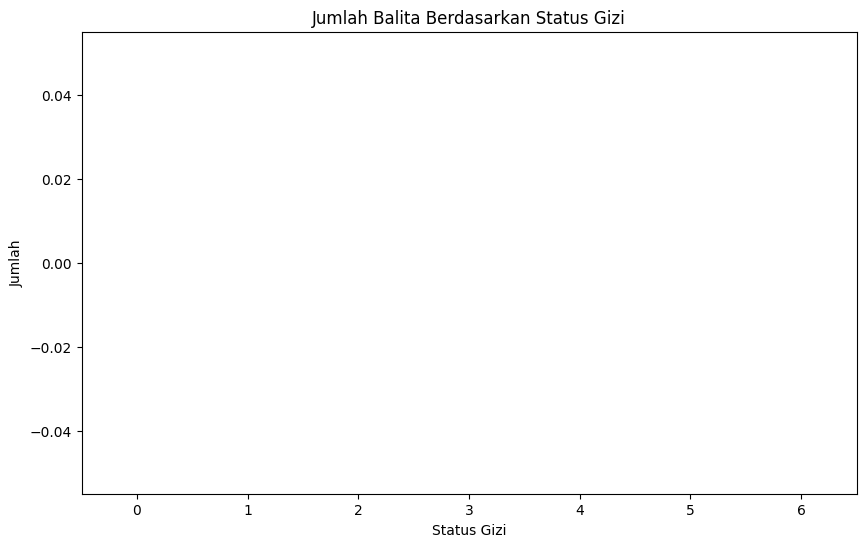

In [49]:
import matplotlib.pyplot as plt
import seaborn as sns

# Menghitung jumlah balita berdasarkan status gizi
status_counts = df['Status Gizi'].value_counts()

# Mengonversi hasil ke dalam DataFrame untuk plotting
status_counts_df = status_counts.reset_index()
status_counts_df.columns = ['Status Gizi', 'Count']
status_counts_df['Status Gizi'] = status_counts_df['Status Gizi'].map({0: 'Severely Stunted', 1: 'Stunted', 2: 'Normal', 3: 'Tinggi'})

# Membuat plot
plt.figure(figsize=(10, 6))
sns.barplot(x='Status Gizi', y='Count', data=status_counts_df, palette='viridis')
plt.title('Jumlah Balita Berdasarkan Status Gizi')
plt.xlabel('Status Gizi')
plt.ylabel('Jumlah')
plt.show()

In [50]:
# mengkodekan jenis kelamin
df['Jenis Kelamin'] = df['Jenis Kelamin'].map({'laki-laki': 0, 'perempuan': 1})

# mengkodekan status gizi
df['Status Gizi'] = df['Status Gizi'].map({'severely stunted': 0, 'stunted': 1, 'normal': 2, 'tinggi': 3})
df

,Umur (bulan),Jenis Kelamin,Tinggi Badan (cm),Status Gizi
0,0,0,44.591973,1
1,0,0,56.705203,3
2,0,0,46.863358,2
3,0,0,47.508026,2
4,0,0,42.743494,0
...,...,...,...,...
120994,60,1,100.600000,2
120995,60,1,98.300000,1
120996,60,1,121.300000,2
120997,60,1,112.200000,2


In [51]:
from sklearn.model_selection import train_test_split

# memisahkan fitur dan target
X = df.iloc[:, 1:6]
X = df.drop('Status Gizi', axis=1)
y = df['Status Gizi']

# membagi dataset menjadi data latih dan data uji
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X

,Umur (bulan),Jenis Kelamin,Tinggi Badan (cm)
0,0,0,44.591973
1,0,0,56.705203
2,0,0,46.863358
3,0,0,47.508026
4,0,0,42.743494
...,...,...,...
120994,60,1,100.600000
120995,60,1,98.300000
120996,60,1,121.300000
120997,60,1,112.200000


In [52]:
from sklearn.neighbors import KNeighborsClassifier

# membuat objek KNN dengan k=3
knn = KNeighborsClassifier(algorithm='kd_tree', n_neighbors=1)

# melatih model KNN dengan data latih
knn.fit(X_train, y_train)

KNeighborsClassifier(algorithm='kd_tree', n_neighbors=1)

In [53]:
from sklearn.metrics import accuracy_score

# membuat prediksi dengan data uji
y_pred = knn.predict(X_test)

# menghitung akurasi model
accuracy = accuracy_score(y_test, y_pred)
print('Akurasi model KNN:', accuracy)

Akurasi model KNN: 0.9990495867768595


<ipython-input-54-2400feb0d285>:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=model_names, y=accuracy_scores, palette='viridis')


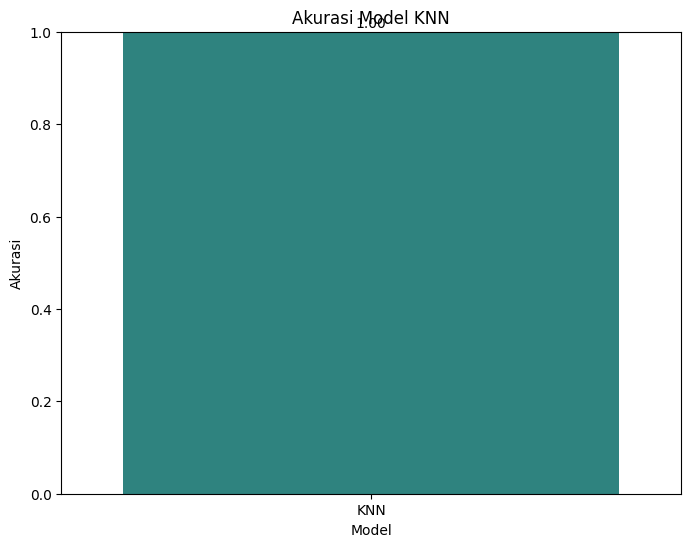

In [54]:
# Membuat plot untuk akurasi model
accuracy_scores = [accuracy]
model_names = ['KNN']

plt.figure(figsize=(8, 6))
sns.barplot(x=model_names, y=accuracy_scores, palette='viridis')
plt.title('Akurasi Model KNN')
plt.xlabel('Model')
plt.ylabel('Akurasi')
plt.ylim(0, 1)
for i in range(len(model_names)):
    plt.text(i, accuracy_scores[i] + 0.01, f'{accuracy_scores[i]:.2f}', ha='center')
plt.show()

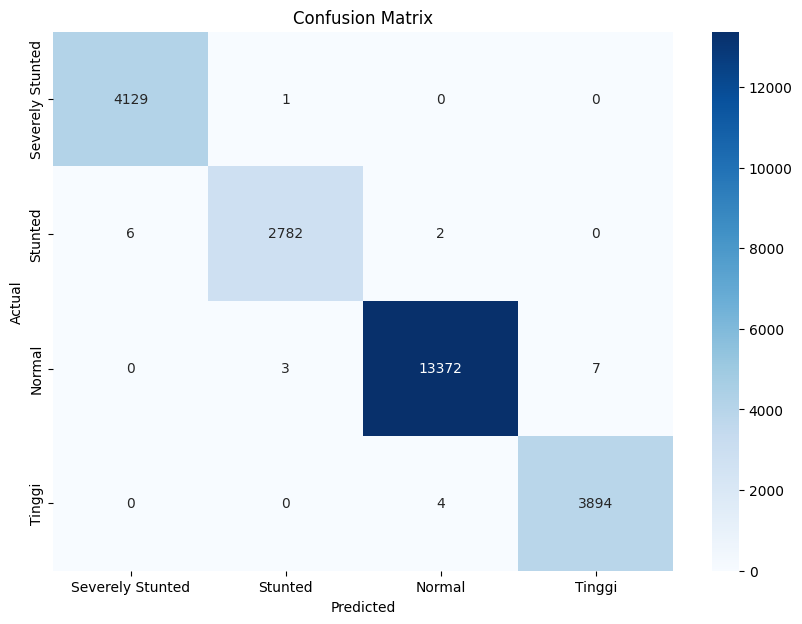

In [55]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Membuat confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Label untuk confusion matrix
labels = ['Severely Stunted', 'Stunted', 'Normal', 'Tinggi']

# Membuat heatmap dari confusion matrix
plt.figure(figsize=(10, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

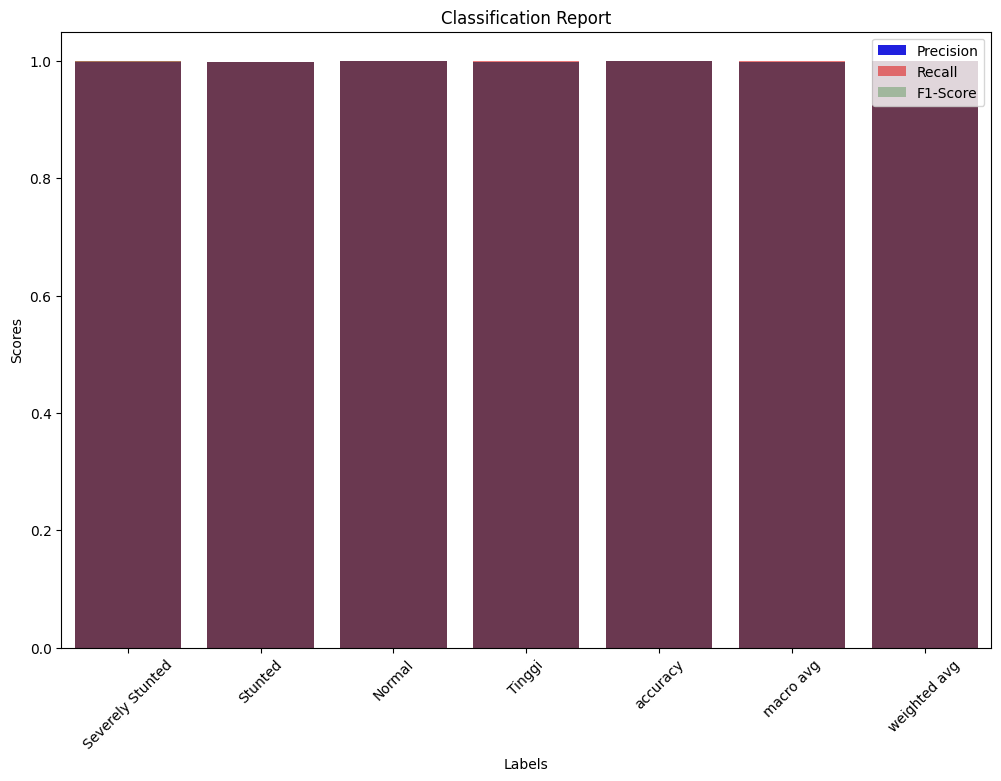

In [56]:
# Classification Report
report = classification_report(y_test, y_pred, target_names=labels, output_dict=True)

# Mengonversi hasil ke dalam DataFrame
report_df = pd.DataFrame(report).transpose()

# Membuat plot untuk classification report
plt.figure(figsize=(12, 8))
sns.barplot(x=report_df.index, y='precision', data=report_df, color='b', label='Precision')
sns.barplot(x=report_df.index, y='recall', data=report_df, color='r', alpha=0.6, label='Recall')
sns.barplot(x=report_df.index, y='f1-score', data=report_df, color='g', alpha=0.3, label='F1-Score')

plt.title('Classification Report')
plt.xlabel('Labels')
plt.ylabel('Scores')
plt.legend()
plt.xticks(rotation=45)
plt.show()

In [40]:
from sklearn.model_selection import cross_val_score

print('Cross val: ', cross_val_score(knn, y_test.values.reshape(-1, 1), y_pred, cv = 5))
print('Accuracy : ', np.mean(cross_val_score(knn, y_test.values.reshape(-1, 1), y_pred)))

Cross val:  [0.99855372 0.99876033 0.99917355 0.99958678 0.99917355]
Accuracy :  0.9990495867768594


In [41]:
# Mapping dari nilai numerik ke label status gizi
status_gizi_mapping = {0: 'severely stunted', 1: 'stunted', 2: 'normal', 3: 'tinggi'}

# Testing model
test = pd.DataFrame({'Umur (bulan)': [20], 'Jenis Kelamin': [0], 'Tinggi Badan (cm)': [70.2]})

# Membuat prediksi
pred = knn.predict(test)

# Mengonversi hasil prediksi ke label aslinya
pred_label = status_gizi_mapping[pred[0]]

print("Predicted Score = {}, which means the child's nutritional status is '{}'".format(pred[0], pred_label))

Predicted Score = 0, which means the child's nutritional status is 'severely stunted'


In [42]:
# Export the model
import joblib

joblib.dump(knn, 'knn.model')

['knn.model']

In [43]:
# Menyalin file ke Google Drive
import shutil

# Salin file ke direktori Google Drive
shutil.copy('knn.model', '/content/drive/My Drive/Stunting KNN/knn.model')

'/content/drive/My Drive/Stunting KNN/knn.model'